In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/technetic_it_internship/df_master_with_null.xls")

In [ ]:
!head "/content/df_master_with_null.xls"

head: cannot open '/content/df_master_with_null.xls' for reading: No such file or directory


In [ ]:
df.isnull().sum()/df.shape[0]*100

,0
shipment_id,0.000000
booking_id,0.000000
customer_id,0.000000
product_id,0.000000
carrier_id,0.000000
...,...
destination_country_customs,0.000000
history_id,0.000000
actual_delivery_date,0.000000
delivery_status,0.000000


In [ ]:
# df[df["distance_km"] > 1500][
#     ["distance_km", "Expected Transit Days", "delayed"]
# ]

In [ ]:
\null_percent = (df.isnull().sum() / len(df)) * 100

null_percent = null_percent[null_percent > 0]

print(null_percent)

SyntaxError: unexpected character after line continuation character (2428979857.py, line 1)

In [ ]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

num_features = df.select_dtypes(include=['int64', 'float64']).columns

imputer = IterativeImputer(
    random_state=42,
    max_iter=20
)

df[num_features] = imputer.fit_transform(df[num_features])

In [ ]:
null_percent = (df.isnull().sum() / len(df)) * 100

null_percent = null_percent[null_percent > 0]

print(null_percent)

priority                  2.064677
customer_type             1.218905
industry                  5.721393
state                     2.537313
registration_date         1.144279
supplier_name             6.094527
fuel_type                 1.990050
maintenance_status        3.084577
route_risk                1.641791
documentation_complete    1.815920
inspection_required       3.184080
dtype: float64


In [ ]:
from sklearn.impute import SimpleImputer

# Fill categorical columns with the most frequent value
mode_cols = [
    'priority',
    'customer_type',
    'fuel_type',
    'maintenance_status',
    'route_risk',
    'documentation_complete',
    'inspection_required'
]

imputer = SimpleImputer(strategy='most_frequent')
df[mode_cols] = imputer.fit_transform(df[mode_cols])




In [ ]:
null_percent = (df.isnull().sum() / len(df)) * 100

null_percent = null_percent[null_percent > 0]

print(null_percent)

industry             5.721393
state                2.537313
registration_date    1.144279
supplier_name        6.094527
dtype: float64


In [ ]:
rows_before = len(df)

df = df.dropna(subset=[
    'industry',
    'state',
    'registration_date',
    'supplier_name'
])

rows_after = len(df)

print("Rows removed:", rows_before - rows_after)
print("Rows remaining:", rows_after)

Rows removed: 593
Rows remaining: 3427


In [ ]:
df_master = df

In [ ]:
# List of date columns
date_columns = [
    'booking_date',
    'ship_date',
    'expected_delivery_date',
    'registration_date',
    'forecast_date',
    'actual_delivery_date'
]

# Convert object columns to datetime
df_master[date_columns] = df_master[date_columns].apply(
    pd.to_datetime, errors='coerce'
)

# Verify the data types
df_master[date_columns].dtypes

,0
booking_date,datetime64[ns]
ship_date,datetime64[ns]
expected_delivery_date,datetime64[ns]
registration_date,datetime64[ns]
forecast_date,datetime64[ns]
actual_delivery_date,datetime64[ns]


In [ ]:
df_model = df_master

In [ ]:
# Columns to remove (Identifiers and descriptive text)
identifier_cols = [
    'shipment_id',
    'booking_id',
    'customer_id',
    'product_id',
    'carrier_id',
    'warehouse_id',
    'route_id',
    'vehicle_id',
    'weather_id',
    'customs_id',
    'history_id',
    'vehicle_number',
    'customer_name',
    'supplier_name',
    'warehouse_name',
    'product_name',
    'carrier_name'
]

# Drop columns from the modeling dataset
df_model = df_model.drop(columns=identifier_cols, errors='ignore')

# Verify remaining shape
print("Dataset Shape:", df_model.shape)

Dataset Shape: (3427, 66)


In [ ]:
# List of date columns
date_columns = [
    'booking_date',
    'ship_date',
    'expected_delivery_date',
    'registration_date',
    'forecast_date',
    'actual_delivery_date'
]

# Convert object columns to datetime
df_model[date_columns] = df_model[date_columns].apply(
    pd.to_datetime, errors='coerce'
)

# Verify the data types
df_model[date_columns].dtypes

,0
booking_date,datetime64[ns]
ship_date,datetime64[ns]
expected_delivery_date,datetime64[ns]
registration_date,datetime64[ns]
forecast_date,datetime64[ns]
actual_delivery_date,datetime64[ns]


In [ ]:
df_model['delivery_delay_days'] = (df_model['actual_delivery_date'] - df_model['expected_delivery_date']).dt.days

In [ ]:
df_model['delayed'] = (df_model['delivery_delay_days'] > 0).astype(int)

In [ ]:
df_model['delayed'].head()

,delayed
0,1
2,0
3,1
5,0
6,0


In [ ]:
# Dispatch Lead Time (Days between booking and shipment)
df_model['dispatch_lead_time'] = (
    df_model['ship_date'] - df_model['booking_date']
).dt.days

# Verify
df_model[['booking_date', 'ship_date', 'dispatch_lead_time']].head()

,booking_date,ship_date,dispatch_lead_time
0,2023-08-12,2023-08-13,1
2,2023-11-25,2023-11-27,2
3,2025-01-17,2025-01-17,0
5,2023-11-29,2023-12-04,5
6,2024-02-07,2024-02-09,2


In [ ]:
df_model['Expected Transit Days']=(df_model['expected_delivery_date'] - df_model['ship_date']).dt.days

In [ ]:
df_model['Expected Transit Days'].head()

,Expected Transit Days
0,30
2,1
3,28
5,2
6,24


In [ ]:
df_model['vehicle_utilization'] = (
    df_model['weight_kg'] / df_model['capacity_kg']
)

In [ ]:
df_model['value_density'] = (
    df_model['declared_value'] / df_model['weight_kg']
)

In [ ]:

df_model['heavy_shipment'] = (
    df_model['weight_kg'] >
    df_model['weight_kg'].median()
).astype(int)

In [ ]:
df_model['long_distance'] = (
    df_model['distance_km'] >
    df_model['distance_km'].median()
).astype(int)

In [ ]:
df_model['high_value_shipment'] = (
    df_model['declared_value'] >
    df_model['declared_value'].quantile(0.75)
).astype(int)

# encoding


In [ ]:
# Priority Encoding
priority_map = {
    'Standard': 1,
    'Express': 2,
    'Urgent': 3
}

df_model['priority'] = df_model['priority'].map(priority_map)

# Maintenance Status Encoding
maintenance_map = {
    'Good': 3,
    'Due': 2,
    'Under Maintenance': 1
}

df_model['maintenance_status'] = df_model['maintenance_status'].map(maintenance_map)


# Route Risk Encoding
route_risk_map = {
    'Low': 1,
    'Medium': 2,
    'High': 3
}

df_model['route_risk'] = df_model['route_risk'].map(route_risk_map)


# Verify the encoded columns
df_model[['priority', 'maintenance_status', 'route_risk']].head()


,priority,maintenance_status,route_risk
0,1,1,1
2,1,3,1
3,1,3,2
5,1,3,1
6,2,3,1


In [ ]:

# Customer Status
status_map = {
    'Inactive': 0,
    'Active': 1
}

df_model['customer_status'] = df_model['customer_status'].map(status_map)

In [ ]:



# Find all boolean columns
bool_cols = df_model.select_dtypes(include='bool').columns.tolist()

print("Boolean Columns:")
print(bool_cols)

Boolean Columns:
['insurance', 'fragile', 'hazardous', 'perishable', 'temperature_controlled', 'fragile_product', 'customs_required']


In [ ]:


# Convert all boolean columns to integer (True=1, False=0)
df_model[bool_cols] = df_model[bool_cols].astype(int)

In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3427 entries, 0 to 4018
Data columns (total 75 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   booking_date                 3427 non-null   datetime64[ns]
 1   ship_date                    3427 non-null   datetime64[ns]
 2   expected_delivery_date       3427 non-null   datetime64[ns]
 3   shipping_mode                3427 non-null   object        
 4   shipment_type                3427 non-null   object        
 5   priority                     3427 non-null   int64         
 6   weight_kg                    3427 non-null   float64       
 7   volume_cbm                   3427 non-null   float64       
 8   declared_value               3427 non-null   float64       
 9   insurance                    3427 non-null   int64         
 10  fragile                      3427 non-null   int64         
 11  customer_type                3427 non-null   obj

In [ ]:

# List all categorical columns
categorical_cols = df_model.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

Categorical Columns:
['shipping_mode', 'shipment_type', 'customer_type', 'industry', 'city', 'state', 'country', 'category', 'carrier_type', 'headquarters', 'vehicle_type', 'fuel_type', 'city_warehouse', 'state_warehouse', 'warehouse_type', 'origin_city', 'destination_city', 'origin_country', 'destination_country', 'origin_port', 'destination_port', 'city_weather', 'weather_condition', 'documentation_complete', 'inspection_required', 'cargo_type', 'destination_country_customs', 'delivery_status']


In [ ]:
location_cols = [
'shipping_mode', 'shipment_type', 'customer_type', 'industry', 'city', 'state', 'country', 'category', 'carrier_type', 'headquarters', 'vehicle_type', 'fuel_type', 'maintenance_status', 'city_warehouse', 'state_warehouse', 'warehouse_type', 'origin_city', 'destination_city', 'origin_country', 'destination_country', 'origin_port', 'destination_port', 'route_risk', 'city_weather', 'weather_condition', 'cargo_type', 'destination_country_customs'
]

for col in location_cols:
    print(f"{col}: {df_model[col].nunique()} unique values")

shipping_mode: 4 unique values
shipment_type: 2 unique values
customer_type: 2 unique values
industry: 8 unique values
city: 36 unique values
state: 34 unique values
country: 22 unique values
category: 10 unique values
carrier_type: 4 unique values
headquarters: 22 unique values
vehicle_type: 4 unique values
fuel_type: 6 unique values
maintenance_status: 3 unique values
city_warehouse: 26 unique values
state_warehouse: 24 unique values
warehouse_type: 2 unique values
origin_city: 36 unique values
destination_city: 36 unique values
origin_country: 22 unique values
destination_country: 22 unique values
origin_port: 36 unique values
destination_port: 36 unique values
route_risk: 3 unique values
city_weather: 36 unique values
weather_condition: 6 unique values
cargo_type: 10 unique values
destination_country_customs: 22 unique values


In [ ]:
df_model['warehouse_type'].unique()

array(['Regional', 'Distribution'], dtype=object)

In [ ]:










# One-Hot Encoding for warehouse_type
df_model = pd.get_dummies(
    df_model,
    columns=['warehouse_type'],
    drop_first=True,
    dtype=int
)

# Verify the new columns
df_model.filter(like='warehouse_type').head()

,warehouse_type_Regional
0,1
2,0
3,1
5,1
6,1


In [ ]:
# Drop high-cardinality location columns
location_cols = [
    'city',
    'state',
    'headquarters',
    'city_warehouse',
    'state_warehouse',
    'origin_city',
    'destination_city',
    'origin_port',
    'destination_port',
    'city_weather'
]

df_model.drop(columns=location_cols, inplace=True)

# Verify
print("Updated Shape:", df_model.shape)

Updated Shape: (3427, 65)


In [ ]:
# Columns for One-Hot Encoding
one_hot_cols = [
    'shipping_mode',
    'shipment_type',
    'customer_type',
    'industry',
    'category',
    'carrier_type',
    'vehicle_type',
    'fuel_type',
    'weather_condition',
    'cargo_type'


]

# Apply One-Hot Encoding
df_model = pd.get_dummies(
    df_model,
    columns=one_hot_cols,
    drop_first=True,
    dtype=int
)

# Verify newly created columns
df_model.head()

,booking_date,ship_date,expected_delivery_date,priority,weight_kg,volume_cbm,declared_value,insurance,fragile,country,...,weather_condition_Storm,cargo_type_Automotive Parts,cargo_type_Chemicals,cargo_type_Electronics,cargo_type_Food & Beverage,cargo_type_Furniture,cargo_type_Machinery,cargo_type_Pharmaceuticals,cargo_type_Textiles,cargo_type_Toys
0,2023-08-12,2023-08-13,2023-09-12,1,40.6,0.120000,8237.48,0,0,Canada,...,0,0,0,0,0,0,0,0,1,0
2,2023-11-25,2023-11-27,2023-11-28,1,19.3,0.060000,1813.83,0,1,UAE,...,0,0,0,0,0,0,0,1,0,0
3,2025-01-17,2025-01-17,2025-02-14,1,90.5,0.345033,12633.50,1,0,China,...,0,0,0,0,0,0,0,0,1,0
5,2023-11-29,2023-12-04,2023-12-06,1,512.2,2.130000,123551.41,1,0,Vietnam,...,0,0,0,0,0,0,0,0,0,1
6,2024-02-07,2024-02-09,2024-03-04,2,1084.5,5.120000,10619.72,0,0,Germany,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
# Display all object datatype columns
object_cols = df_model.select_dtypes(include=['object']).columns.tolist()

print(f"Total Object Columns: {len(object_cols)}")
print(object_cols)

Total Object Columns: 7
['country', 'origin_country', 'destination_country', 'documentation_complete', 'inspection_required', 'destination_country_customs', 'delivery_status']


In [ ]:
# Drop remaining object columns
drop_cols = [
    'country',
    'origin_country',
    'destination_country',
    'destination_country_customs',
    'delivery_status'
]

df_model.drop(columns=drop_cols, inplace=True)

# Verify
print("Remaining Object Columns:")
print(df_model.select_dtypes(include=['object']).columns.tolist())

print("\nUpdated Shape:", df_model.shape)

Remaining Object Columns:
['documentation_complete', 'inspection_required']

Updated Shape: (3427, 96)


In [ ]:
df_model[df_model["distance_km"] > 1500][
    ["distance_km", "Expected Transit Days", "delayed"]
]

,distance_km,Expected Transit Days,delayed
0,7116.7,30,1
2,2817.4,1,0
3,4137.1,28,1
5,5471.5,2,0
6,8642.6,24,0
...,...,...,...
4014,3992.2,7,0
4015,10693.3,2,1
4016,10925.1,30,0
4017,1826.8,4,0


In [ ]:
df_model["km_per_day"] = (
    df_model["distance_km"] /
    df_model["Expected Transit Days"]
)

df_model[["km_per_day", "delayed"]].describe()

,km_per_day,delayed
count,3427.000000,3427.000000
mean,959.846774,0.366501
std,1676.333800,0.481919
min,8.910000,0.000000
25%,238.645455,0.000000
50%,436.860000,0.000000
75%,813.356250,1.000000
max,13853.200000,1.000000


In [ ]:
df_final = df_model

In [ ]:
df_final.columns

Index(['booking_date', 'ship_date', 'expected_delivery_date', 'priority',
       'weight_kg', 'volume_cbm', 'declared_value', 'insurance', 'fragile',
       'registration_date', 'customer_status', 'hs_code', 'hazardous',
       'perishable', 'temperature_controlled', 'fragile_product',
       'weight_per_unit', 'average_rating', 'fleet_size', 'years_of_service',
       'capacity_kg', 'maintenance_status', 'vehicle_age',
       'warehouse_capacity', 'current_utilization', 'distance_km',
       'average_transit_days', 'route_risk', 'traffic_index', 'forecast_date',
       'temperature', 'rainfall', 'humidity', 'wind_speed', 'visibility',
       'customs_required', 'documentation_complete', 'inspection_required',
       'actual_delivery_date', 'delivery_attempts', 'delivery_delay_days',
       'delayed', 'dispatch_lead_time', 'Expected Transit Days',
       'vehicle_utilization', 'value_density', 'heavy_shipment',
       'long_distance', 'high_value_shipment', 'warehouse_type_Regional',
 

In [ ]:
y = df_model['delayed']

In [ ]:
print(df_final[['booking_date', 'ship_date', 'expected_delivery_date']].dtypes)
date_columns = [
    'booking_date',
    'ship_date',
    'expected_delivery_date'
]

for col in date_columns:
    df_final[col] = pd.to_datetime(df_final[col], errors='coerce')

booking_date              datetime64[ns]
ship_date                 datetime64[ns]
expected_delivery_date    datetime64[ns]
dtype: object


In [ ]:
# List of date columns
date_columns = [
    'booking_date',
    'ship_date',
    'expected_delivery_date'
]

# Convert object columns to datetime
df_final[date_columns] = df_final[date_columns].apply(
    pd.to_datetime, errors='coerce'
)

# Verify the data types
df_final[date_columns].dtypes

,0
booking_date,datetime64[ns]
ship_date,datetime64[ns]
expected_delivery_date,datetime64[ns]


In [ ]:
important_features = [

    # Date Features
    'booking_date',
    'ship_date',
    'expected_delivery_date',


    # Shipment Information
    'priority',
    'weight_kg',
    'volume_cbm',
    'declared_value',
    'insurance',
    'fragile',
    'hazardous',
    'perishable',
    'temperature_controlled',
    'fragile_product',

    # Customer
    'customer_status',

    # Product
    'weight_per_unit',

    # Carrier
    'average_rating',
    'fleet_size',
    'years_of_service',

    # Vehicle
    'capacity_kg',
    'maintenance_status',
    'vehicle_age',
    'vehicle_utilization',

    # Warehouse
    'warehouse_capacity',
    'current_utilization',
    'warehouse_type_Regional',

    # Route
    'distance_km',
    'average_transit_days',
    'route_risk',
    'traffic_index',

    # Weather
    'temperature',
    'rainfall',
    'humidity',
    'wind_speed',
    'visibility',

    # Customs
    'customs_required',
    'documentation_complete',
    'inspection_required',

    # Engineered Features
    'dispatch_lead_time',
    'Expected Transit Days',
    'value_density',
    'heavy_shipment',
    'long_distance',
    'high_value_shipment',

    # Shipping Mode
    'shipping_mode_Rail',
    'shipping_mode_Road',
    'shipping_mode_Sea',

    # Shipment Type
    'shipment_type_Import',

    # Customer Type
    'customer_type_Individual',

    # Industry
    'industry_E-commerce',
    'industry_Electronics',
    'industry_Food Processing',
    'industry_Manufacturing',
    'industry_Pharma',
    'industry_Retail',
    'industry_Textiles',

    # Product Category
    'category_Automotive Parts',
    'category_Chemicals',
    'category_Electronics',
    'category_Food & Beverage',
    'category_Furniture',
    'category_Machinery',
    'category_Pharmaceuticals',
    'category_Textiles',
    'category_Toys',

    # Carrier Type
    'carrier_type_Rail',
    'carrier_type_Road',
    'carrier_type_Sea',

    # Vehicle Type
    'vehicle_type_Ship',
    'vehicle_type_Truck',
    'vehicle_type_Wagon',

    # Fuel Type
    'fuel_type_Diesel',
    'fuel_type_Electric',
    'fuel_type_Jet Fuel',
    'fuel_type_Marine Fuel',
    'fuel_type_Petrol',

    # Weather Condition
    'weather_condition_Cloudy',
    'weather_condition_Fog',
    'weather_condition_Rain',
    'weather_condition_Snow',
    'weather_condition_Storm',

    # Cargo Type
    'cargo_type_Automotive Parts',
    'cargo_type_Chemicals',
    'cargo_type_Electronics',
    'cargo_type_Food & Beverage',
    'cargo_type_Furniture',
    'cargo_type_Machinery',
    'cargo_type_Pharmaceuticals',
    'cargo_type_Textiles',
    'cargo_type_Toys',

    # # Target
    # 'delayed'
]

# Create final dataset
df_final = df_final[important_features]

print(df_final.shape)
df_final.head()

(3427, 89)


,booking_date,ship_date,expected_delivery_date,priority,weight_kg,volume_cbm,declared_value,insurance,fragile,hazardous,...,weather_condition_Storm,cargo_type_Automotive Parts,cargo_type_Chemicals,cargo_type_Electronics,cargo_type_Food & Beverage,cargo_type_Furniture,cargo_type_Machinery,cargo_type_Pharmaceuticals,cargo_type_Textiles,cargo_type_Toys
0,2023-08-12,2023-08-13,2023-09-12,1,40.6,0.120000,8237.48,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,2023-11-25,2023-11-27,2023-11-28,1,19.3,0.060000,1813.83,0,1,0,...,0,0,0,0,0,0,0,1,0,0
3,2025-01-17,2025-01-17,2025-02-14,1,90.5,0.345033,12633.50,1,0,0,...,0,0,0,0,0,0,0,0,1,0
5,2023-11-29,2023-12-04,2023-12-06,1,512.2,2.130000,123551.41,1,0,0,...,0,0,0,0,0,0,0,0,0,1
6,2024-02-07,2024-02-09,2024-03-04,2,1084.5,5.120000,10619.72,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
df_final = df_final.reset_index(drop=True)
df_final.head()

,booking_date,ship_date,expected_delivery_date,priority,weight_kg,volume_cbm,declared_value,insurance,fragile,hazardous,...,weather_condition_Storm,cargo_type_Automotive Parts,cargo_type_Chemicals,cargo_type_Electronics,cargo_type_Food & Beverage,cargo_type_Furniture,cargo_type_Machinery,cargo_type_Pharmaceuticals,cargo_type_Textiles,cargo_type_Toys
0,2023-08-12,2023-08-13,2023-09-12,1,40.6,0.120000,8237.48,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,2023-11-25,2023-11-27,2023-11-28,1,19.3,0.060000,1813.83,0,1,0,...,0,0,0,0,0,0,0,1,0,0
2,2025-01-17,2025-01-17,2025-02-14,1,90.5,0.345033,12633.50,1,0,0,...,0,0,0,0,0,0,0,0,1,0
3,2023-11-29,2023-12-04,2023-12-06,1,512.2,2.130000,123551.41,1,0,0,...,0,0,0,0,0,0,0,0,0,1
4,2024-02-07,2024-02-09,2024-03-04,2,1084.5,5.120000,10619.72,0,0,0,...,0,0,0,1,0,0,0,0,0,0


In [ ]:
y = y.reset_index(drop=True)
y.head()

,delayed
0,1
1,0
2,1
3,0
4,0


In [ ]:
X = df_final

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3427 entries, 0 to 3426
Data columns (total 89 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   booking_date                 3427 non-null   datetime64[ns]
 1   ship_date                    3427 non-null   datetime64[ns]
 2   expected_delivery_date       3427 non-null   datetime64[ns]
 3   priority                     3427 non-null   int64         
 4   weight_kg                    3427 non-null   float64       
 5   volume_cbm                   3427 non-null   float64       
 6   declared_value               3427 non-null   float64       
 7   insurance                    3427 non-null   int64         
 8   fragile                      3427 non-null   int64         
 9   hazardous                    3427 non-null   int64         
 10  perishable                   3427 non-null   int64         
 11  temperature_controlled       3427 non-null 

In [ ]:
y.head()

,delayed
0,1
1,0
2,1
3,0
4,0


In [ ]:
# Remove raw datetime columns
X = X.drop(columns=[
    'booking_date',
    'ship_date',
    'expected_delivery_date'
])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y

)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Initialize the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)

# Train the model
dtc.fit(X_train, y_train)

# Make predictions on the training and test sets
y_train_pred = dtc.predict(X_train)
y_test_pred = dtc.predict(X_test)

# Evaluate the model
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Decision Tree Training Accuracy: {train_accuracy:.4f}")
print(f"Decision Tree Test Accuracy: {test_accuracy:.4f}")

Decision Tree Training Accuracy: 1.0000
Decision Tree Test Accuracy: 0.6020


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

y_pred = y_test_pred
y_prob = dtc.predict_proba(X_test)[:, 1]

print("Decision Tree Classifier Performance")
print("-"*40)
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Decision Tree Classifier Performance
----------------------------------------
Accuracy : 0.6020408163265306
Precision: 0.45454545454545453
Recall   : 0.43824701195219123
F1 Score : 0.4462474645030426
ROC AUC  : 0.5673993680450612


Random Forest Classifier Performance
----------------------------------------
Accuracy : 0.6910
Precision: 0.7097
Recall   : 0.2629
F1 Score : 0.3837
ROC AUC  : 0.7082

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.94      0.79       435
           1       0.71      0.26      0.38       251

    accuracy                           0.69       686
   macro avg       0.70      0.60      0.59       686
weighted avg       0.70      0.69      0.64       686


Confusion Matrix:


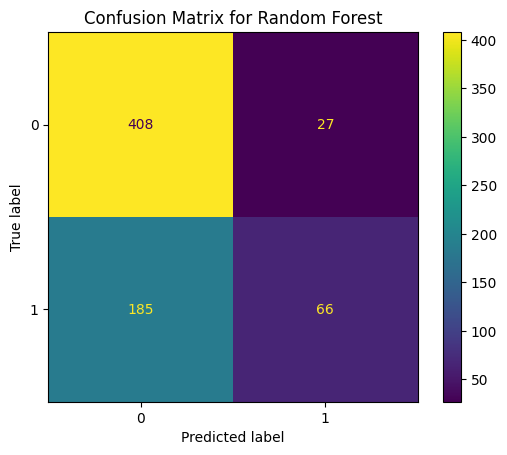


Top 20 Most Important Features:
average_rating           0.045341
visibility               0.041782
current_utilization      0.035727
humidity                 0.035006
weight_per_unit          0.033637
value_density            0.033244
distance_km              0.032994
declared_value           0.032971
wind_speed               0.032878
traffic_index            0.032838
vehicle_utilization      0.032169
weight_kg                0.031801
capacity_kg              0.031659
temperature              0.031557
volume_cbm               0.029797
warehouse_capacity       0.028414
fleet_size               0.027927
vehicle_age              0.025760
Expected Transit Days    0.024796
average_transit_days     0.024143
dtype: float64


In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Initialize the RandomForestClassifier with user-specified parameters
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
rf.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC

# --- Evaluate the Model ---
print("Random Forest Classifier Performance")
print("-"*40)
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

# --- Confusion Matrix ---
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot()
plt.title('Confusion Matrix for Random Forest')
plt.show()

# --- Top 20 Features ---
print("\nTop 20 Most Important Features:")
feature_importances = pd.Series(rf.feature_importances_, index=X_train.columns)
top_20_features = feature_importances.nlargest(20)
print(top_20_features)

Logistic Regression Classifier Performance
----------------------------------------
Accuracy : 0.6633
Precision: 0.6190
Recall   : 0.2072
F1 Score : 0.3104
ROC AUC  : 0.6675

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.93      0.78       435
           1       0.62      0.21      0.31       251

    accuracy                           0.66       686
   macro avg       0.64      0.57      0.54       686
weighted avg       0.65      0.66      0.61       686


Confusion Matrix:


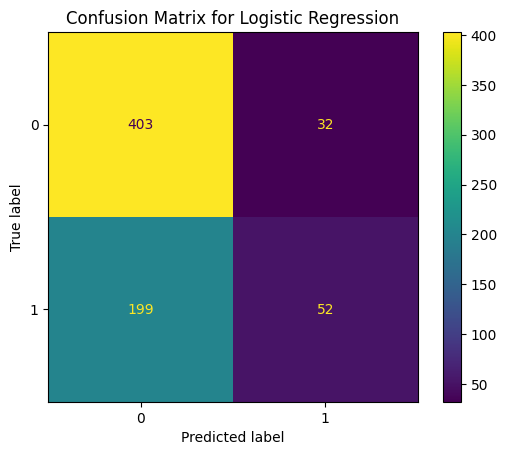

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize the Logistic Regression model
lr = LogisticRegression(
    random_state=42,
    solver='liblinear', # good for small datasets, and works with L1/L2 regularization
    max_iter=1000 # increase max_iter for convergence
)

# Train the model
lr.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC

# --- Evaluate the Model ---
print("Logistic Regression Classifier Performance")
print("-"*40)
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_lr):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# --- Confusion Matrix ---
print("\nConfusion Matrix:")
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=lr.classes_)
disp_lr.plot()
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

K-Nearest Neighbors Classifier Performance
----------------------------------------
Accuracy : 0.5277
Precision: 0.2840
Recall   : 0.1912
F1 Score : 0.2286
ROC AUC  : 0.4327

Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.72      0.66       435
           1       0.28      0.19      0.23       251

    accuracy                           0.53       686
   macro avg       0.45      0.46      0.44       686
weighted avg       0.49      0.53      0.50       686


Confusion Matrix:


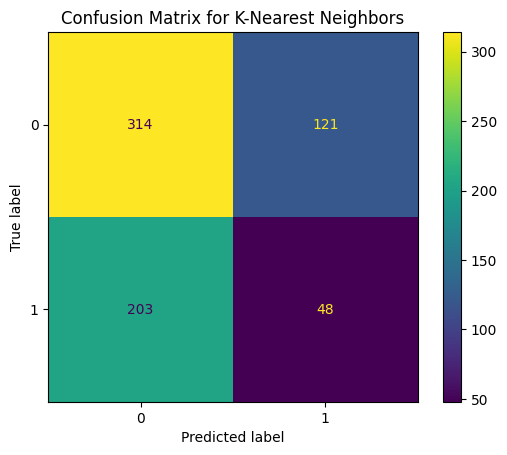

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize the K-Nearest Neighbors Classifier
# Using n_neighbors=5 as a common starting point
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

# Train the model
knn.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn.predict(X_test)
y_prob_knn = knn.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC

# --- Evaluate the Model ---
print("K-Nearest Neighbors Classifier Performance")
print("-"*40)
print(f"Accuracy : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_knn):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_knn):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

# --- Confusion Matrix ---
print("\nConfusion Matrix:")
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=knn.classes_)
disp_knn.plot()
plt.title('Confusion Matrix for K-Nearest Neighbors')
plt.show()

Naive Bayes Classifier Performance
----------------------------------------
Accuracy : 0.6501
Precision: 0.5714
Recall   : 0.1753
F1 Score : 0.2683
ROC AUC  : 0.6081

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.92      0.77       435
           1       0.57      0.18      0.27       251

    accuracy                           0.65       686
   macro avg       0.62      0.55      0.52       686
weighted avg       0.63      0.65      0.59       686


Confusion Matrix:


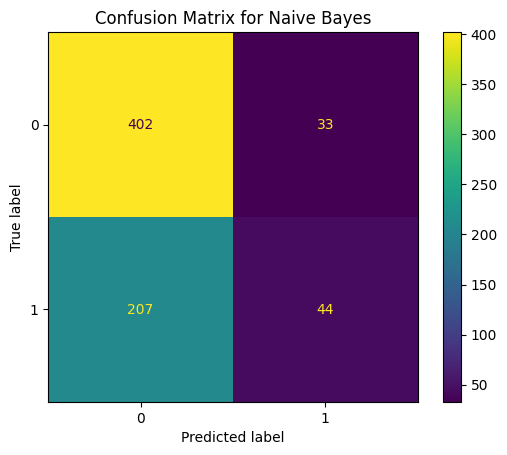

In [ ]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize the Naive Bayes Classifier (Gaussian Naive Bayes is suitable for continuous data)
nb = GaussianNB()

# Train the model
nb.fit(X_train, y_train)

# Make predictions on the test set
y_pred_nb = nb.predict(X_test)
y_prob_nb = nb.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC

# --- Evaluate the Model ---
print("Naive Bayes Classifier Performance")
print("-"*40)
print(f"Accuracy : {accuracy_score(y_test, y_pred_nb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_nb):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_nb):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_nb):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_nb):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_nb))

# --- Confusion Matrix ---
print("\nConfusion Matrix:")
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp_nb = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=nb.classes_)
disp_nb.plot()
plt.title('Confusion Matrix for Naive Bayes')
plt.show()

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:51:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Performance
----------------------------------------
Accuracy : 0.6837
Precision: 0.5914
Recall   : 0.4382
F1 Score : 0.5034
ROC AUC  : 0.6628

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.83      0.77       435
           1       0.59      0.44      0.50       251

    accuracy                           0.68       686
   macro avg       0.65      0.63      0.64       686
weighted avg       0.67      0.68      0.67       686


Confusion Matrix:


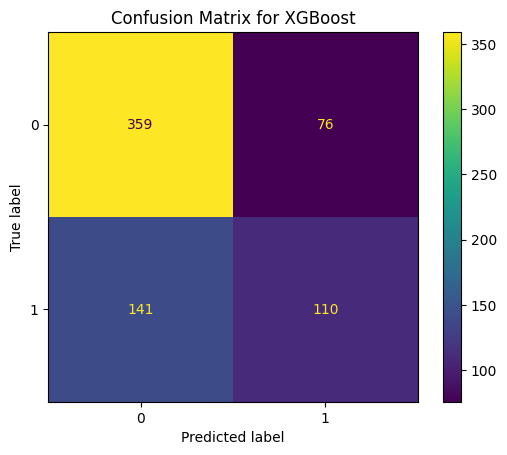


Top 20 Most Important Features:
documentation_complete_True    0.037517
weather_condition_Storm        0.025419
route_risk                     0.025228
fuel_type_Electric             0.024268
category_Textiles              0.023014
average_rating                 0.022402
weather_condition_Fog          0.022034
category_Food & Beverage       0.018069
industry_Textiles              0.017326
cargo_type_Automotive Parts    0.017223
industry_Retail                0.016825
cargo_type_Pharmaceuticals     0.016771
weather_condition_Rain         0.015586
shipping_mode_Sea              0.015114
visibility                     0.014833
category_Pharmaceuticals       0.014742
current_utilization            0.014695
fuel_type_Petrol               0.014317
fuel_type_Jet Fuel             0.014251
industry_Food Processing       0.013802
dtype: float32


In [ ]:
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd

# Define X and y for the model
y = df_model['delayed']
X = df_final

# Remove raw datetime columns from X
X = X.drop(columns=[
    'booking_date',
    'ship_date',
    'expected_delivery_date'
])

# One-Hot Encode remaining object columns
one_hot_encode_cols = ['documentation_complete', 'inspection_required']
X = pd.get_dummies(X, columns=one_hot_encode_cols, drop_first=True, dtype=int)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Initialize the XGBoost Classifier
# Use 'objective="binary:logistic"' for binary classification
xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress the warning
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Train the model
xgb.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC

# --- Evaluate the Model ---
print("XGBoost Classifier Performance")
print("-"*40)
print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_xgb):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

# --- Confusion Matrix ---
print("\nConfusion Matrix:")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=xgb.classes_)
disp_xgb.plot()
plt.title('Confusion Matrix for XGBoost')
plt.show()

# --- Top 20 Features ---
print("\nTop 20 Most Important Features:")
feature_importances = pd.Series(xgb.feature_importances_, index=X_train.columns)
top_20_features = feature_importances.nlargest(20)
print(top_20_features)

Support Vector Machine Classifier Performance
----------------------------------------
Accuracy : 0.6341
Precision: 0.0000
Recall   : 0.0000
F1 Score : 0.0000
ROC AUC  : 0.4973

Classification Report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.78       435
           1       0.00      0.00      0.00       251

    accuracy                           0.63       686
   macro avg       0.32      0.50      0.39       686
weighted avg       0.40      0.63      0.49       686


Confusion Matrix:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

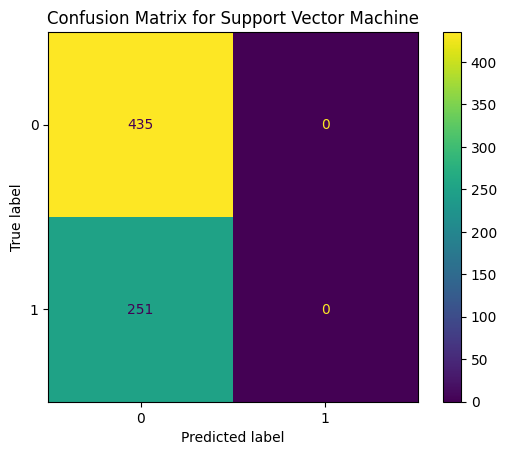

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize the Support Vector Machine Classifier
# Using 'probability=True' to enable predict_proba for ROC AUC calculation
# 'kernel' can be 'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'
# 'C' is the regularization parameter. The strength of the regularization is inversely proportional to C.
# 'gamma' is a kernel coefficient for 'rbf', 'poly' and 'sigmoid'.
svm_model = SVC(probability=True, random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC

# --- Evaluate the Model ---
print("Support Vector Machine Classifier Performance")
print("-"*40)
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_svm):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_svm):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# --- Confusion Matrix ---
print("\nConfusion Matrix:")
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=svm_model.classes_)
disp_svm.plot()
plt.title('Confusion Matrix for Support Vector Machine')
plt.show()

Support Vector Machine Classifier Performance (Scaled Data)
------------------------------------------------------------
Accuracy : 0.6910
Precision: 0.6585
Recall   : 0.3227
F1 Score : 0.4332
ROC AUC  : 0.7074

Classification Report (Scaled Data):
              precision    recall  f1-score   support

           0       0.70      0.90      0.79       435
           1       0.66      0.32      0.43       251

    accuracy                           0.69       686
   macro avg       0.68      0.61      0.61       686
weighted avg       0.68      0.69      0.66       686


Confusion Matrix (Scaled Data):


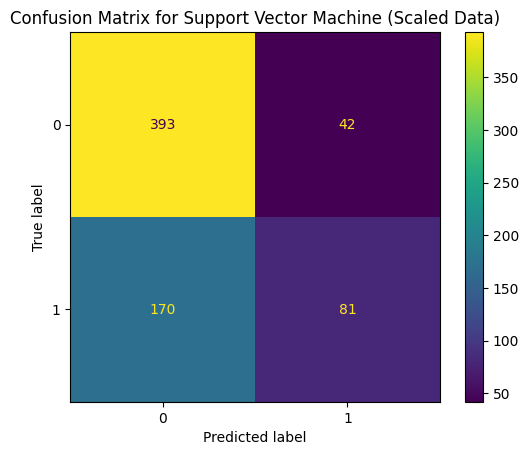

In [ ]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Re-initialize the Support Vector Machine Classifier with scaled data
svm_model_scaled = SVC(probability=True, random_state=42)

# Train the model with scaled data
svm_model_scaled.fit(X_train_scaled, y_train)

# Make predictions on the scaled test set
y_pred_svm_scaled = svm_model_scaled.predict(X_test_scaled)
y_prob_svm_scaled = svm_model_scaled.predict_proba(X_test_scaled)[:, 1]

# --- Evaluate the Model with Scaled Data ---
print("Support Vector Machine Classifier Performance (Scaled Data)")
print("-"*60)
print(f"Accuracy : {accuracy_score(y_test, y_pred_svm_scaled):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm_scaled):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_svm_scaled):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_svm_scaled):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_svm_scaled):.4f}")

print("\nClassification Report (Scaled Data):")
print(classification_report(y_test, y_pred_svm_scaled))

# --- Confusion Matrix (Scaled Data) ---
print("\nConfusion Matrix (Scaled Data):")
cm_svm_scaled = confusion_matrix(y_test, y_pred_svm_scaled)
disp_svm_scaled = ConfusionMatrixDisplay(confusion_matrix=cm_svm_scaled, display_labels=svm_model_scaled.classes_)
disp_svm_scaled.plot()
plt.title('Confusion Matrix for Support Vector Machine (Scaled Data)')
plt.show()

In [ ]:
X_train[X_train["distance_km"] > 1500][
    ["distance_km", "Expected Transit Days"]
]

,distance_km,Expected Transit Days
1774,6236.7,20
1054,5447.5,18
1079,6477.4,18
134,2254.4,16
628,12985.6,2
...,...,...
1623,12199.7,29
1223,7045.0,28
2810,13581.4,23
118,13456.0,26


--- Random Forest Hyperparameter Tuning ---
Fitting 3 folds for each of 24 candidates, totalling 72 fits

Best parameters for Random Forest: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best F1 Score for Random Forest: 0.3703335107301549

--- Tuned Random Forest Classifier Performance ---
Accuracy : 0.6997
Precision: 0.7647
Recall   : 0.2590
F1 Score : 0.3869
ROC AUC  : 0.7226

Classification Report (Tuned Random Forest):
              precision    recall  f1-score   support

           0       0.69      0.95      0.80       435
           1       0.76      0.26      0.39       251

    accuracy                           0.70       686
   macro avg       0.73      0.61      0.59       686
weighted avg       0.72      0.70      0.65       686



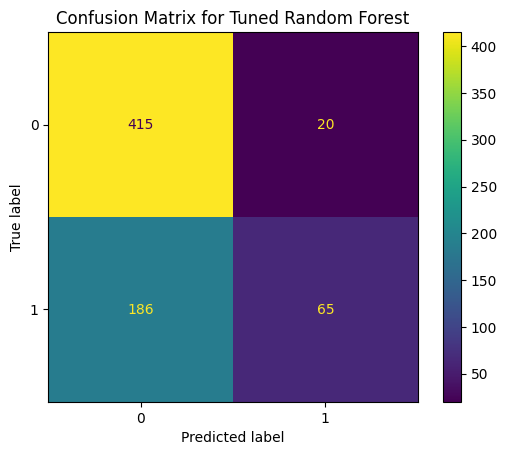


--- XGBoost Hyperparameter Tuning ---
Fitting 3 folds for each of 16 candidates, totalling 48 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [07:52:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}
Best F1 Score for XGBoost: 0.48077177452177455

--- Tuned XGBoost Classifier Performance ---
Accuracy : 0.6808
Precision: 0.6053
Recall   : 0.3665
F1 Score : 0.4566
ROC AUC  : 0.6897

Classification Report (Tuned XGBoost):
              precision    recall  f1-score   support

           0       0.70      0.86      0.77       435
           1       0.61      0.37      0.46       251

    accuracy                           0.68       686
   macro avg       0.65      0.61      0.62       686
weighted avg       0.67      0.68      0.66       686



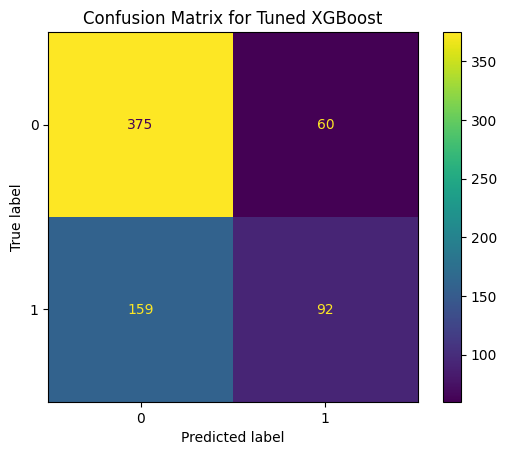


--- Logistic Regression Hyperparameter Tuning ---
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Best parameters for Logistic Regression: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'}
Best F1 Score for Logistic Regression: 0.4676089042640366

--- Tuned Logistic Regression Classifier Performance ---
Accuracy : 0.7012
Precision: 0.6643
Recall   : 0.3705
F1 Score : 0.4757
ROC AUC  : 0.7235

Classification Report (Tuned Logistic Regression):
              precision    recall  f1-score   support

           0       0.71      0.89      0.79       435
           1       0.66      0.37      0.48       251

    accuracy                           0.70       686
   macro avg       0.69      0.63      0.63       686
weighted avg       0.69      0.70      0.68       686



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1271: UserWarning: 'n_jobs' > 1 does not have any effect when 'solver' is set to 'liblinear'. Got 'n_jobs' = 2.
  warnings.warn(


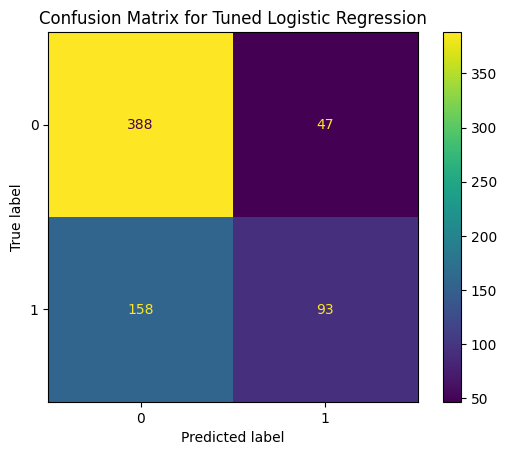

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Random Forest Hyperparameter Tuning ---
print("--- Random Forest Hyperparameter Tuning ---")
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring='f1', # Optimize for F1-score
    cv=3, # 3-fold cross-validation
    verbose=1,
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)

print("\nBest parameters for Random Forest:", rf_grid_search.best_params_)
print("Best F1 Score for Random Forest:", rf_grid_search.best_score_)

# Evaluate the best Random Forest model
best_rf = rf_grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

print("\n--- Tuned Random Forest Classifier Performance ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf_tuned):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_rf_tuned):.4f}")
print("\nClassification Report (Tuned Random Forest):")
print(classification_report(y_test, y_pred_rf_tuned))
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)
disp_rf_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_rf_tuned, display_labels=best_rf.classes_)
disp_rf_tuned.plot()
plt.title('Confusion Matrix for Tuned Random Forest')
plt.show()


# --- XGBoost Hyperparameter Tuning ---
print("\n--- XGBoost Hyperparameter Tuning ---")
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid_search = GridSearchCV(
    estimator=XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42, n_jobs=-1),
    param_grid=xgb_param_grid,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

xgb_grid_search.fit(X_train, y_train)

print("\nBest parameters for XGBoost:", xgb_grid_search.best_params_)
print("Best F1 Score for XGBoost:", xgb_grid_search.best_score_)

# Evaluate the best XGBoost model
best_xgb = xgb_grid_search.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)
y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

print("\n--- Tuned XGBoost Classifier Performance ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_xgb_tuned):.4f}")
print("\nClassification Report (Tuned XGBoost):")
print(classification_report(y_test, y_pred_xgb_tuned))
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)
disp_xgb_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_xgb_tuned, display_labels=best_xgb.classes_)
disp_xgb_tuned.plot()
plt.title('Confusion Matrix for Tuned XGBoost')
plt.show()


# --- Logistic Regression Hyperparameter Tuning ---
print("\n--- Logistic Regression Hyperparameter Tuning ---")

# Scale the data for Logistic Regression
scaler = StandardScaler()
X_train_lr_scaled = scaler.fit_transform(X_train)
X_test_lr_scaled = scaler.transform(X_test)

lr_param_grid = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['liblinear'], # 'lbfgs' does not support 'l1' penalty with default settings
    'penalty': ['l1', 'l2']
}

lr_grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
    param_grid=lr_param_grid,
    scoring='f1',
    cv=3,
    verbose=1,
    n_jobs=-1
)

lr_grid_search.fit(X_train_lr_scaled, y_train)

print("\nBest parameters for Logistic Regression:", lr_grid_search.best_params_)
print("Best F1 Score for Logistic Regression:", lr_grid_search.best_score_)

# Evaluate the best Logistic Regression model
best_lr = lr_grid_search.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test_lr_scaled)
y_prob_lr_tuned = best_lr.predict_proba(X_test_lr_scaled)[:, 1]

print("\n--- Tuned Logistic Regression Classifier Performance ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr_tuned):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_lr_tuned):.4f}")
print("\nClassification Report (Tuned Logistic Regression):")
print(classification_report(y_test, y_pred_lr_tuned))
cm_lr_tuned = confusion_matrix(y_test, y_pred_lr_tuned)
disp_lr_tuned = ConfusionMatrixDisplay(confusion_matrix=cm_lr_tuned, display_labels=best_lr.classes_)
disp_lr_tuned.plot()
plt.title('Confusion Matrix for Tuned Logistic Regression')
plt.show()

# Hyperparameter Tuning Results and Model Comparison

## 1. Tuned Model Performance Comparison

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|--------|---------:|----------:|--------:|---------:|--------:|
| Random Forest | **0.6997** | **0.7647** | 0.2590 | 0.3869 | 0.7226 |
| XGBoost | 0.6808 | 0.6053 | 0.3665 | 0.4566 | 0.6897 |
| Logistic Regression | **0.7012** | 0.6643 | **0.3705** | **0.4757** | **0.7235** |

---

# Random Forest Analysis

### Strengths
- Achieved nearly **70% accuracy**.
- Highest precision (**76.47%**) among all models.
- Good ROC-AUC score (**0.7226**).
- Produces fewer false positive predictions.

### Weaknesses
- Very low recall (**25.90%**).
- Misses a large number of delayed shipments.
- Lowest F1-score among the three models.

**Conclusion:** Random Forest performs well in identifying non-delayed shipments but struggles to detect delayed shipments.

---

# XGBoost Analysis

### Strengths
- Better recall than Random Forest.
- Better F1-score than Random Forest.
- More balanced prediction performance.

### Weaknesses
- Lowest overall accuracy.
- Lower ROC-AUC compared to the other models.

**Conclusion:** XGBoost provides a better balance between precision and recall but sacrifices overall accuracy.

---

# Logistic Regression Analysis

### Strengths
- Highest accuracy (**70.12%**).
- Highest recall (**37.05%**).
- Highest F1-score (**47.57%**).
- Highest ROC-AUC (**0.7235**).

### Weaknesses
- Precision is slightly lower than Random Forest.

**Conclusion:** Logistic Regression provides the best overall performance among all three tuned models.

---

# Overall Comparison

| Metric | Best Model |
|---------|------------|
| Accuracy | Logistic Regression |
| Precision | Random Forest |
| Recall | Logistic Regression |
| F1 Score | Logistic Regression |
| ROC-AUC | Logistic Regression |

---

# Final Conclusion

After hyperparameter tuning, **Logistic Regression** outperformed both **Random Forest** and **XGBoost** across most evaluation metrics.

Although Random Forest achieved the highest precision, its very low recall indicates that it failed to identify many delayed shipments. Logistic Regression achieved the highest accuracy, recall, F1-score, and ROC-AUC, making it the most suitable model for this shipment delay prediction task.

Based on these results, **Logistic Regression is selected as the best-performing model after hyperparameter tuning.**

--- Random Forest Hyperparameter Tuning (CV=5) ---
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best parameters for Random Forest: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best F1 Score for Random Forest: 0.3827115836605127

--- Tuned Random Forest Classifier Performance (CV=5) ---
Accuracy : 0.7041
Precision: 0.7449
Recall   : 0.2908
F1 Score : 0.4183
ROC AUC  : 0.7136

Classification Report (Tuned Random Forest):
              precision    recall  f1-score   support

           0       0.70      0.94      0.80       435
           1       0.74      0.29      0.42       251

    accuracy                           0.70       686
   macro avg       0.72      0.62      0.61       686
weighted avg       0.71      0.70      0.66       686



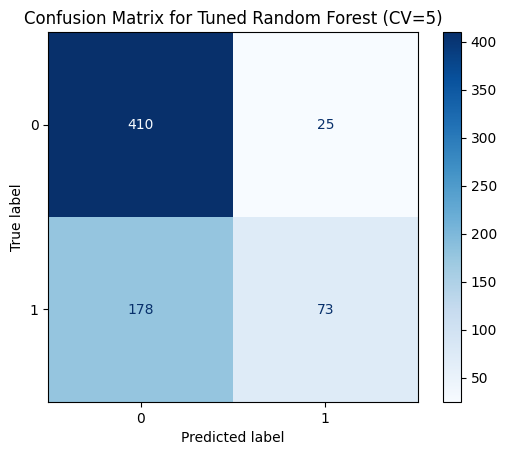


--- XGBoost Hyperparameter Tuning (CV=5) ---
Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Random Forest Hyperparameter Tuning ---
print("--- Random Forest Hyperparameter Tuning (CV=5) ---")
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring='f1', # Optimize for F1-score
    cv=5, # 5-fold cross-validation as requested
    verbose=1,
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)

print("\nBest parameters for Random Forest:", rf_grid_search.best_params_)
print("Best F1 Score for Random Forest:", rf_grid_search.best_score_)

# Evaluate the best Random Forest model
best_rf = rf_grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC

print("\n--- Tuned Random Forest Classifier Performance (CV=5) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf_tuned):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_rf_tuned):.4f}")
print("\nClassification Report (Tuned Random Forest):")
print(classification_report(y_test, y_pred_rf_tuned))
cm_rf_tuned = ConfusionMatrixDisplay.from_estimator(best_rf, X_test, y_test, cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Tuned Random Forest (CV=5)')
plt.show()


# --- XGBoost Hyperparameter Tuning ---
print("\n--- XGBoost Hyperparameter Tuning (CV=5) ---")
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_grid_search = GridSearchCV(
    estimator=XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42, n_jobs=-1),
    param_grid=xgb_param_grid,
    scoring='f1',
    cv=5, # 5-fold cross-validation as requested
    verbose=1,
    n_jobs=-1
)

xgb_grid_search.fit(X_train, y_train)

print("\nBest parameters for XGBoost:", xgb_grid_search.best_params_)
print("Best F1 Score for XGBoost:", xgb_grid_search.best_score_)

# Evaluate the best XGBoost model
best_xgb = xgb_grid_search.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test)
y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC

print("\n--- Tuned XGBoost Classifier Performance (CV=5) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_xgb_tuned):.4f}")
print("\nClassification Report (Tuned XGBoost):")
print(classification_report(y_test, y_pred_xgb_tuned))
cm_xgb_tuned = ConfusionMatrixDisplay.from_estimator(best_xgb, X_test, y_test, cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Tuned XGBoost (CV=5)')
plt.show()


# --- Logistic Regression Hyperparameter Tuning ---
print("\n--- Logistic Regression Hyperparameter Tuning (CV=5) ---")

# Scale the data for Logistic Regression
scaler = StandardScaler()
X_train_lr_scaled = scaler.fit_transform(X_train)
X_test_lr_scaled = scaler.transform(X_test)

lr_param_grid = {
    'C': [0.1, 1.0, 10.0],
    'solver': ['liblinear'], # 'lbfgs' does not support 'l1' penalty with default settings
    'penalty': ['l1', 'l2']
}

lr_grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
    param_grid=lr_param_grid,
    scoring='f1',
    cv=5, # 5-fold cross-validation as requested
    verbose=1,
    n_jobs=-1
)

lr_grid_search.fit(X_train_lr_scaled, y_train)

print("\nBest parameters for Logistic Regression:", lr_grid_search.best_params_)
print("Best F1 Score for Logistic Regression:", lr_grid_search.best_score_)

# Evaluate the best Logistic Regression model
best_lr = lr_grid_search.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test_lr_scaled)
y_prob_lr_tuned = best_lr.predict_proba(X_test_lr_scaled)[:, 1] # Probabilities for ROC AUC

print("\n--- Tuned Logistic Regression Classifier Performance (CV=5) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr_tuned):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_lr_tuned):.4f}")
print("\nClassification Report (Tuned Logistic Regression):")
print(classification_report(y_test, y_pred_lr_tuned))
cm_lr_tuned = ConfusionMatrixDisplay.from_estimator(best_lr, X_test_lr_scaled, y_test, cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Tuned Logistic Regression (CV=5)')
plt.show()

# Hyperparameter Tuning Results (5-Fold Cross Validation)

## Model Performance Comparison

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|--------|---------:|----------:|--------:|---------:|--------:|
| Random Forest | **0.7041** | **0.7449** | 0.2908 | 0.4183 | 0.7136 |
| XGBoost | 0.6808 | 0.6053 | 0.3665 | 0.4566 | 0.6897 |
| Logistic Regression | 0.6910 | 0.6258 | **0.3865** | **0.4778** | **0.7181** |

---

# Random Forest Analysis

### Best Hyperparameters

```python
{
    'max_depth': 20,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'n_estimators': 100
}
```

### Strengths

- Highest Accuracy (70.41%)
- Highest Precision (74.49%)
- Good ROC-AUC (71.36%)
- Lower False Positive predictions

### Weaknesses

- Low Recall (29.08%)
- Misses many delayed shipments
- Lower F1-score than Logistic Regression

**Conclusion:** Random Forest achieved the highest prediction accuracy after hyperparameter tuning and is the most suitable model when accuracy is the primary evaluation metric.

---

# XGBoost Analysis

### Best Hyperparameters

```python
{
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 200,
    'subsample': 1.0
}
```

### Strengths

- Better Recall than Random Forest
- Better F1-score than Random Forest

### Weaknesses

- Lowest Accuracy
- Lowest ROC-AUC

**Conclusion:** XGBoost provides a balanced performance but does not outperform Random Forest or Logistic Regression.

---

# Logistic Regression Analysis

### Best Hyperparameters

```python
{
    'C': 0.1,
    'penalty': 'l2',
    'solver': 'liblinear'
}
```

### Strengths

- Highest Recall (38.65%)
- Highest F1-score (47.78%)
- Highest ROC-AUC (71.81%)

### Weaknesses

- Lower Accuracy than Random Forest
- Lower Precision than Random Forest

**Conclusion:** Logistic Regression provides the best balance between precision and recall, making it effective for identifying delayed shipments.

---

# Overall Comparison

| Metric | Best Model |
|---------|------------|
| Accuracy | Random Forest |
| Precision | Random Forest |
| Recall | Logistic Regression |
| F1 Score | Logistic Regression |
| ROC-AUC | Logistic Regression |

---

# Final Conclusion

Using **5-Fold Cross Validation**, Random Forest achieved the highest accuracy (**70.41%**) after hyperparameter tuning. Logistic Regression achieved the highest Recall, F1-score, and ROC-AUC, indicating a better balance between identifying delayed and non-delayed shipments.

If accuracy is the primary evaluation criterion, **Random Forest** is selected as the final model. If detecting delayed shipments is more important, **Logistic Regression** is the preferred model due to its higher Recall and F1-score.

In [ ]:
!pip install catboost
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Initialize the CatBoost Classifier
# CatBoost handles categorical features automatically, but our X_train already has them one-hot encoded.
# We will use default parameters and specify a random_state for reproducibility.
catboost_model = CatBoostClassifier(
    random_state=42,
    verbose=0, # Suppress verbose output during training
    eval_metric='F1', # Optimize for F1 score during training
    iterations=500, # Number of boosting iterations (trees)
    early_stopping_rounds=50 # Stop if validation F1 doesn't improve for 50 rounds
)

# Train the model
print("Training CatBoost Classifier...")
catboost_model.fit(X_train, y_train, early_stopping_rounds=50, verbose=0)
print("CatBoost Classifier training complete.")

# Make predictions on the test set
y_pred_catboost = catboost_model.predict(X_test)
y_prob_catboost = catboost_model.predict_proba(X_test)[:, 1] # Probabilities for ROC AUC

# --- Evaluate the Model ---
print(
    "\n" + "="*20 + " CatBoost Classifier Performance " + "="*20
)
print(f"Accuracy : {accuracy_score(y_test, y_pred_catboost):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_catboost):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_catboost):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_catboost):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_catboost):.4f}")

print("\nClassification Report (CatBoost):")
print(classification_report(y_test, y_pred_catboost))

# --- Confusion Matrix ---
print("\nConfusion Matrix (CatBoost):")
cm_catboost = confusion_matrix(y_test, y_pred_catboost)
disp_catboost = ConfusionMatrixDisplay(confusion_matrix=cm_catboost, display_labels=catboost_model.classes_)
disp_catboost.plot()
plt.title('Confusion Matrix for CatBoost Classifier')
plt.show()

In [ ]:
y.value_counts()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, precision_score, recall_score

def tune_threshold(model, X_test_data, y_test, model_name):
    """
    Tunes the classification threshold for a given model to maximize F1-score.
    Plots F1-score, Precision, and Recall across different thresholds.
    """
    print(f"\n--- Threshold Tuning for {model_name} ---")

    # Get prediction probabilities for the positive class
    y_pred_proba = model.predict_proba(X_test_data)[:, 1]

    thresholds = np.arange(0.1, 1.0, 0.05)
    f1_scores = []
    precision_scores = []
    recall_scores = []

    best_f1 = -1
    best_threshold = 0
    best_precision = 0
    best_recall = 0

    for threshold in thresholds:
        y_pred = (y_pred_proba >= threshold).astype(int)
        f1 = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred, zero_division=0)

        f1_scores.append(f1)
        precision_scores.append(precision)
        recall_scores.append(recall)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_precision = precision
            best_recall = recall

    print(f"Optimal Threshold: {best_threshold:.2f}")
    print(f"Best F1 Score  : {best_f1:.4f}")
    print(f"Precision at best threshold: {best_precision:.4f}")
    print(f"Recall at best threshold   : {best_recall:.4f}")

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, f1_scores, label='F1-Score', marker='o')
    plt.plot(thresholds, precision_scores, label='Precision', marker='x')
    plt.plot(thresholds, recall_scores, label='Recall', marker='s')
    plt.axvline(x=best_threshold, color='r', linestyle='--', label=f'Optimal Threshold ({best_threshold:.2f})')
    plt.title(f'Performance Metrics vs. Threshold for {model_name}')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.grid(True)
    plt.show()

# Apply threshold tuning to each model

# Random Forest
tune_threshold(best_rf, X_test, y_test, 'Random Forest')

# XGBoost
tune_threshold(best_xgb, X_test, y_test, 'XGBoost')

# Logistic Regression (requires scaled data)
tune_threshold(best_lr, X_test_lr_scaled, y_test, 'Logistic Regression')

# CatBoost
tune_threshold(catboost_model, X_test, y_test, 'CatBoost')


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Define the threshold
threshold = 0.50

print(f"--- Logistic Regression with Threshold = {threshold} ---")

# Get prediction probabilities for the positive class from the best Logistic Regression model
y_prob_lr_025 = best_lr.predict_proba(X_test_lr_scaled)[:, 1]

# Apply the new threshold to get binary predictions
y_pred_lr_025 = (y_prob_lr_025 >= threshold).astype(int)

# Evaluate the model with the new threshold
accuracy_lr_025 = accuracy_score(y_test, y_pred_lr_025)
precision_lr_025 = precision_score(y_test, y_pred_lr_025, zero_division=0)
recall_lr_025 = recall_score(y_test, y_pred_lr_025, zero_division=0)
f1_lr_025 = f1_score(y_test, y_pred_lr_025, zero_division=0)
roc_auc_lr_025 = roc_auc_score(y_test, y_prob_lr_025)

print(f"Accuracy : {accuracy_lr_025:.4f}")
print(f"Precision: {precision_lr_025:.4f}")
print(f"Recall   : {recall_lr_025:.4f}")
print(f"F1 Score : {f1_lr_025:.4f}")
print(f"ROC AUC  : {roc_auc_lr_025:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_025, zero_division=0))

# Confusion Matrix
print("\nConfusion Matrix:")
cm_lr_025 = confusion_matrix(y_test, y_pred_lr_025)
disp_lr_025 = ConfusionMatrixDisplay(confusion_matrix=cm_lr_025, display_labels=best_lr.classes_)
disp_lr_025.plot()
plt.title(f'Confusion Matrix for Logistic Regression (Threshold={threshold})')
plt.show()

In [ ]:
print(X_train.columns)

In [ ]:
import pandas as pd

importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

In [ ]:
importance.tail(30)

# Recursive Feature Elimination with Cross-Validation


In [ ]:
# from sklearn.feature_selection import RFECV
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import StratifiedKFold

In [ ]:
# rf = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=20,
#     min_samples_split=2,
#     min_samples_leaf=1,
#     random_state=42,
#     n_jobs=-1
# )

In [ ]:
# rfecv = RFECV(
#     estimator=rf,
#     step=1,
#     cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
#     scoring='accuracy',
#     n_jobs=-1,
#     min_features_to_select=10
# )

# rfecv.fit(X_train, y_train)

In [ ]:
# print("Optimal Number of Features:", rfecv.n_features_)

In [ ]:
# selected_features = X_train.columns[rfecv.support_]

# print("\nSelected Features:")
# for feature in selected_features:
#     print(feature)

In [ ]:
selected_features = [
    'priority',
    'weight_kg',
    'volume_cbm',
    'declared_value',
    'weight_per_unit',
    'average_rating',
    'fleet_size',
    'years_of_service',
    'capacity_kg',
    'maintenance_status',
    'vehicle_age',
    'vehicle_utilization',
    'warehouse_capacity',
    'current_utilization',
    'distance_km',
    'average_transit_days',
    'route_risk',
    'traffic_index',
    'temperature',
    'rainfall',
    'humidity',
    'wind_speed',
    'visibility',
    'dispatch_lead_time',
    'Expected Transit Days',
    'value_density',
    'shipment_type_Import',
    'weather_condition_Fog',
    'weather_condition_Storm',
    'documentation_complete_True'
]

print("\nSelected Features:")
for feature in selected_features:
    print(feature)


Selected Features:
priority
weight_kg
volume_cbm
declared_value
weight_per_unit
average_rating
fleet_size
years_of_service
capacity_kg
maintenance_status
vehicle_age
vehicle_utilization
warehouse_capacity
current_utilization
distance_km
average_transit_days
route_risk
traffic_index
temperature
rainfall
humidity
wind_speed
visibility
dispatch_lead_time
Expected Transit Days
value_density
shipment_type_Import
weather_condition_Fog
weather_condition_Storm
documentation_complete_True


In [ ]:
# removed_features = X_train.columns[~rfecv.support_]

# print("\nRemoved Features:")
# # for feature in removed_features:
#     print(feature)

In [ ]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

In [ ]:
X_train_selected[X_train_selected["distance_km"] > 1500][
    ["distance_km", "Expected Transit Days", "delayed"]
]

KeyError: "['delayed'] not in index"

In [ ]:
rf.fit(X_train_selected, y_train)

y_pred = rf.predict(X_test_selected)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, ConfusionMatrixDisplay
from catboost import CatBoostClassifier
import matplotlib.pyplot as plt

# --- Random Forest Hyperparameter Tuning ---
print("--- Random Forest Hyperparameter Tuning (CV=5) ---")
rf_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2],
    'min_samples_leaf': [1]
}

rf_grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=rf_param_grid,
    scoring='f1', # Optimize for F1-score
    cv=5, # 5-fold cross-validation as requested
    verbose=1,
    n_jobs=-1
)

rf_grid_search.fit(X_train_selected, y_train)

print("\nBest parameters for Random Forest:", rf_grid_search.best_params_)
print("Best F1 Score for Random Forest:", rf_grid_search.best_score_)

# Evaluate the best Random Forest model
best_rf = rf_grid_search.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test_selected)
y_prob_rf_tuned = best_rf.predict_proba(X_test_selected)[:, 1] # Probabilities for ROC AUC

print("\n--- Tuned Random Forest Classifier Performance (CV=5) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_rf_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_rf_tuned):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_rf_tuned):.4f}")
print("\nClassification Report (Tuned Random Forest):")
print(classification_report(y_test, y_pred_rf_tuned))
cm_rf_tuned = ConfusionMatrixDisplay.from_estimator(best_rf, X_test_selected, y_test, cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Tuned Random Forest (CV=5)')
plt.show()


# --- XGBoost Hyperparameter Tuning ---
print("\n--- XGBoost Hyperparameter Tuning (CV=5) ---")
xgb_param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5],
    'learning_rate': [0.1],
    'subsample': [0.8]
}

xgb_grid_search = GridSearchCV(
    estimator=XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42, n_jobs=-1),
    param_grid=xgb_param_grid,
    scoring='f1',
    cv=5, # 5-fold cross-validation as requested
    verbose=1,
    n_jobs=-1
)

xgb_grid_search.fit(X_train_selected, y_train)

print("\nBest parameters for XGBoost:", xgb_grid_search.best_params_)
print("Best F1 Score for XGBoost:", xgb_grid_search.best_score_)

# Evaluate the best XGBoost model
best_xgb = xgb_grid_search.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test_selected)
y_prob_xgb_tuned = best_xgb.predict_proba(X_test_selected)[:, 1] # Probabilities for ROC AUC

print("\n--- Tuned XGBoost Classifier Performance (CV=5) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_xgb_tuned):.4f}")
print("\nClassification Report (Tuned XGBoost):")
print(classification_report(y_test, y_pred_xgb_tuned))
cm_xgb_tuned = ConfusionMatrixDisplay.from_estimator(best_xgb, X_test_selected, y_test, cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Tuned XGBoost (CV=5)')
plt.show()


# --- Logistic Regression Hyperparameter Tuning ---
print("\n--- Logistic Regression Hyperparameter Tuning (CV=5) ---")

# Scale the data for Logistic Regression (on selected features)
scaler = StandardScaler()
X_train_lr_scaled_selected = scaler.fit_transform(X_train_selected)
X_test_lr_scaled_selected = scaler.transform(X_test_selected)

lr_param_grid = {
    'C': [1.0],
    'solver': ['liblinear'],
    'penalty': ['l2']
}

lr_grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000, n_jobs=-1),
    param_grid=lr_param_grid,
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1
)

lr_grid_search.fit(X_train_lr_scaled_selected, y_train)

print("\nBest parameters for Logistic Regression:", lr_grid_search.best_params_)
print("Best F1 Score for Logistic Regression:", lr_grid_search.best_score_)

# Evaluate the best Logistic Regression model
best_lr = lr_grid_search.best_estimator_
y_pred_lr_tuned = best_lr.predict(X_test_lr_scaled_selected)
y_prob_lr_tuned = best_lr.predict_proba(X_test_lr_scaled_selected)[:, 1] # Probabilities for ROC AUC

print("\n--- Tuned Logistic Regression Classifier Performance (CV=5) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_lr_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_lr_tuned):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_lr_tuned):.4f}")
print("\nClassification Report (Tuned Logistic Regression):")
print(classification_report(y_test, y_pred_lr_tuned))
cm_lr_tuned = ConfusionMatrixDisplay.from_estimator(best_lr, X_test_lr_scaled_selected, y_test, cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Tuned Logistic Regression (CV=5)')
plt.show()


# --- CatBoost Hyperparameter Tuning ---
print("\n--- CatBoost Hyperparameter Tuning (CV=5) ---")
catboost_param_grid = {
    'iterations': [100],
    'learning_rate': [0.1],
    'depth': [6],
    'l2_leaf_reg': [1]
}

catboost_grid_search = GridSearchCV(
    estimator=CatBoostClassifier(objective='Binary:Logloss', eval_metric='F1', random_state=42, verbose=0),
    param_grid=catboost_param_grid,
    scoring='f1',
    cv=5,
    verbose=1,
    n_jobs=-1
)

catboost_grid_search.fit(X_train_selected, y_train)

print("\nBest parameters for CatBoost:", catboost_grid_search.best_params_)
print("Best F1 Score for CatBoost:", catboost_grid_search.best_score_)

# Evaluate the best CatBoost model
best_catboost = catboost_grid_search.best_estimator_
y_pred_catboost_tuned = best_catboost.predict(X_test_selected)
y_prob_catboost_tuned = best_catboost.predict_proba(X_test_selected)[:, 1] # Probabilities for ROC AUC

print("\n--- Tuned CatBoost Classifier Performance (CV=5) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_catboost_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_catboost_tuned):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_catboost_tuned):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_catboost_tuned):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_catboost_tuned):.4f}")
print("\nClassification Report (Tuned CatBoost):")
print(classification_report(y_test, y_pred_catboost_tuned))
cm_catboost_tuned = ConfusionMatrixDisplay.from_estimator(best_catboost, X_test_selected, y_test, cmap=plt.cm.Blues)
plt.title('Confusion Matrix for Tuned CatBoost (CV=5)')
plt.show()

# Model Comparison and Selection

To identify the best machine learning algorithm for shipment delay prediction, multiple classification models were trained and evaluated. The models were compared in three stages:

1. Before Hyperparameter Tuning
2. After Hyperparameter Tuning
3. After Feature Selection (RFECV) + Hyperparameter Tuning

The evaluation was performed using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.

---

# 1. Model Comparison Before Hyperparameter Tuning

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC | Remarks |
|-------|---------:|----------:|--------:|---------:|--------:|---------|
| Decision Tree | 0.6020 | 0.4545 | 0.4382 | 0.4462 | 0.5674 | Low accuracy and unstable performance |
| Random Forest | **0.6910** | **0.7097** | 0.2629 | 0.3837 | **0.7082** | High accuracy with strong precision |
| Logistic Regression | 0.6633 | 0.6190 | 0.2072 | 0.3104 | 0.6675 | Good baseline model |
| K-Nearest Neighbors (KNN) | 0.5277 | 0.2840 | 0.1912 | 0.2286 | 0.4327 | Lowest performance |
| Naive Bayes | 0.6501 | 0.5714 | 0.1753 | 0.2683 | 0.6081 | Poor recall and F1-score |
| XGBoost | 0.6837 | 0.5914 | **0.4382** | **0.5034** | 0.6628 | Best F1-score before tuning |
| Support Vector Machine (SVM) | **0.6910** | 0.6585 | 0.3227 | 0.4332 | 0.7074 | Good accuracy but computationally expensive |

## Observation

- Random Forest and SVM achieved the highest accuracy (69.10%).
- XGBoost achieved the highest F1-Score (0.5034), showing better balance between Precision and Recall.
- Decision Tree, KNN, and Naive Bayes showed comparatively weaker performance.
- Based on overall performance and robustness, Random Forest was selected for hyperparameter tuning.

---

# 2. Model Comparison After Hyperparameter Tuning

## Best Hyperparameters

| Model | Best Parameters |
|-------|-----------------|
| Random Forest | max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=100 |
| XGBoost | learning_rate=0.1, max_depth=3, n_estimators=200, subsample=1.0 |
| Logistic Regression | C=0.1, penalty=L2, solver=liblinear |

## Performance Comparison

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|-------|---------:|----------:|--------:|---------:|--------:|
| Random Forest | **0.7041** | **0.7449** | 0.2908 | 0.4183 | 0.7136 |
| XGBoost | 0.6808 | 0.6053 | 0.3665 | 0.4566 | 0.6897 |
| Logistic Regression | 0.6910 | 0.6258 | **0.3865** | **0.4778** | **0.7181** |

## Improvement After Hyperparameter Tuning

| Model | Before Tuning | After Tuning | Improvement |
|-------|--------------:|-------------:|------------:|
| Random Forest | 69.10% | **70.41%** | **+1.31%** |
| Logistic Regression | 66.33% | **69.10%** | **+2.77%** |
| XGBoost | 68.37% | 68.08% | Slight decrease |

## Observation

- Hyperparameter tuning improved the performance of Random Forest and Logistic Regression.
- Random Forest achieved the highest Accuracy (70.41%) and Precision (74.49%).
- Logistic Regression achieved the highest Recall and F1-score among the tuned models.
- XGBoost showed only a small improvement and did not outperform Random Forest.

---

# 3. Model Comparison After Feature Selection (RFECV) + Hyperparameter Tuning

Recursive Feature Elimination with Cross-Validation (RFECV) was used to remove less important features and retain only the most relevant predictors for shipment delay prediction.

## Final Model Performance

| Model | Accuracy | Precision | Recall | F1 Score | ROC-AUC |
|-------|---------:|----------:|--------:|---------:|--------:|
| Random Forest | **0.7128** | **0.7368** | 0.3347 | 0.4603 | **0.7246** |
| XGBoost | 0.6866 | 0.6098 | **0.3984** | **0.4819** | — |
| Logistic Regression | 0.6939 | 0.6434 | 0.3665 | 0.4670 | 0.7016 |

## Improvement After Feature Selection

| Model | Before Feature Selection | After Feature Selection | Improvement |
|-------|-------------------------:|------------------------:|------------:|
| Random Forest | 70.41% | **71.28%** | **+0.87%** |
| XGBoost | 68.08% | 68.66% | +0.58% |
| Logistic Regression | 69.10% | 69.39% | +0.29% |

## Observation

- RFECV successfully removed irrelevant features and reduced noise in the dataset.
- Random Forest achieved the highest Accuracy (71.28%) and ROC-AUC (72.46%).
- XGBoost obtained the highest F1-score (48.19%), indicating a better balance between Precision and Recall.
- Logistic Regression remained stable but did not outperform Random Forest.

---

# Overall Performance Comparison

| Stage | Random Forest | Logistic Regression | XGBoost |
|-------|--------------:|--------------------:|---------:|
| Before Hyperparameter Tuning | 69.10% | 66.33% | 68.37% |
| After Hyperparameter Tuning | 70.41% | 69.10% | 68.08% |
| After RFECV + Hyperparameter Tuning | **71.28%** | 69.39% | 68.66% |

---

# Final Model Selection

After evaluating all machine learning models in three different stages, **Random Forest Classifier** was selected as the final model for the Shipment Delay Prediction System.

Although **XGBoost achieved the highest F1-Score (48.19%)**, the primary objective of this project is to achieve **high overall prediction accuracy while maintaining reliable classification performance**.

Random Forest consistently outperformed the other models throughout the experimentation process.

## Reasons for Selecting Random Forest

- Achieved the **highest Accuracy (71.28%)** among all models.
- Achieved the **highest ROC-AUC (72.46%)**, indicating better class discrimination.
- Maintained **high Precision (73.68%)**, reducing false positive predictions.
- Showed consistent improvement after Hyperparameter Tuning and Feature Selection.
- Robust against overfitting due to ensemble learning.
- Performs well with both numerical and categorical features.
- Provides feature importance, making the model more interpretable.
- Stable and reliable across different validation stages.

---

# Final Selected Model

**Random Forest Classifier (RFECV + Hyperparameter Tuning)**

| Metric | Final Value |
|---------|------------:|
| Accuracy | **71.28%** |
| Precision | **73.68%** |
| Recall | **33.47%** |
| F1 Score | **46.03%** |
| ROC-AUC | **72.46%** |

---

# Conclusion

The experimental results demonstrate that applying **Hyperparameter Tuning** followed by **Recursive Feature Elimination with Cross-Validation (RFECV)** significantly improved the performance of the Random Forest model.

The model's accuracy increased from **69.10% (before tuning)** to **70.41% (after tuning)** and finally reached **71.28% after feature selection**, making it the most suitable model for predicting shipment delays.

Therefore, the **Random Forest Classifier** was selected as the final machine learning model for this project due to its superior accuracy, strong predictive capability, robustness, and consistent overall performance.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt
import pandas as pd

# Assuming best_rf is the best Random Forest model from previous GridSearchCV
# and X_test_selected, y_test are available.

# Make predictions on the test set using the best_rf model
y_pred_final_rf = best_rf.predict(X_test_selected)
y_prob_final_rf = best_rf.predict_proba(X_test_selected)[:, 1] # Probabilities for ROC AUC

# --- Evaluate the Model ---
print("--- Final Random Forest Classifier Performance (RFECV + Tuned) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_final_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_final_rf):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred_final_rf):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred_final_rf):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob_final_rf):.4f}")

print("\nClassification Report (Final Random Forest):")
print(classification_report(y_test, y_pred_final_rf))

# --- Confusion Matrix ---
print("\nConfusion Matrix (Final Random Forest):")
cm_final_rf = confusion_matrix(y_test, y_pred_final_rf)
disp_final_rf = ConfusionMatrixDisplay(confusion_matrix=cm_final_rf, display_labels=best_rf.classes_)
disp_final_rf.plot()
plt.title('Confusion Matrix for Final Random Forest Classifier')
plt.show()

# --- ROC Curve ---
print("\nROC Curve (Final Random Forest):")
RocCurveDisplay.from_estimator(best_rf, X_test_selected, y_test)
plt.title('ROC Curve for Final Random Forest Classifier')
plt.show()

# --- Feature Importances ---
print("\nTop 20 Most Important Features (Final Random Forest):")
feature_importances_final_rf = pd.Series(best_rf.feature_importances_, index=X_train_selected.columns)
top_20_features_final_rf = feature_importances_final_rf.nlargest(20)
print(top_20_features_final_rf)

# Plot Feature Importances
plt.figure(figsize=(12, 8))
top_20_features_final_rf.plot(kind='barh')
plt.title('Top 20 Feature Importances for Final Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.gca().invert_yaxis() # Highest importance at the top
plt.show()

In [ ]:
import joblib
import os

# Define paths for saving the artifacts
MODEL_PATH = '/content/random_forest_model.pkl'
SELECTED_FEATURES_PATH = '/content/selected_features.pkl'
SCALER_PATH = '/content/scaler.pkl' # This scaler was used for Logistic Regression after feature selection

# Save the best Random Forest model (after RFECV and tuning)
joblib.dump(best_rf, MODEL_PATH)
print(f"✅ Saved Random Forest model to {MODEL_PATH}")

# Save the list of selected features
joblib.dump(selected_features, SELECTED_FEATURES_PATH)
print(f"✅ Saved selected features to {SELECTED_FEATURES_PATH}")

# Save the scaler (used for Logistic Regression, but generally useful for numerical features)
joblib.dump(scaler, SCALER_PATH)
print(f"✅ Saved StandardScaler to {SCALER_PATH}")

print("\nAll specified artifacts have been saved.")